In [1]:
import numpy as np
import pandas as pd 

import h5py

import matplotlib.pyplot as plt

%matplotlib inline

In [13]:
def get_max_min_wavelengths(file):
    counter_start = 0
    counter_end = 0
    total_list = []
    for i in file:
        empty_list = []
        wavelength_grid = file[i]["wavelength_grid"][:]
        start_value = file[i]["wavelength_grid"][0]
        end_value = file[i]["wavelength_grid"][-1]
        step_value = np.abs(file[i]["wavelength_grid"][2] - file[i]["wavelength_grid"][1])
        length_wave = len(wavelength_grid)
        length_flux = len(file[i]["flux"][:])
        empty_list.append(start_value)
        empty_list.append(end_value)
        
        total_list.append(empty_list)

    wavelength_start_list = [row[0] for row in total_list]
    wavelength_end_list = [row[1] for row in total_list]

    for pixels in wavelength_start_list:
        if pixels > 4000:
            counter_start+=1

    for pixels in wavelength_end_list:
        if pixels < 8500:
            counter_end += 1

    return f"Number of stars with starting wavelength pixels greater than 4000 A: {counter_start} and Number of stars with ending wavelength lesser than 8500 A: {counter_end}"


In [3]:
sdss_data = h5py.File("/home/arbiter/projects/Survey-invariant-generalization/data/sdss_final_ready.h5")
lamost_data = h5py.File("/home/arbiter/projects/Survey-invariant-generalization/data/lamost_combined.h5")

In [14]:
get_max_min_wavelengths(sdss_data)

'Number of stars with starting wavelength pixels greater than 4000 A: 15 and Number of stars with ending wavelength lesser than 8500 A: 28'

In [11]:
get_max_min_wavelengths(lamost_data)

'Number of stars with starting wavelength pixels greater than 4000 A: 0 and Number of stars with ending wavelength lesser than 8500 A: 0'

In [19]:
def get_number_of_pixels(file):
    counter_start = 0
    counter_end = 0
    total_list = []
    for i in file:
        empty_list = []
        wavelength_grid = file[i]["wavelength_grid"][:]
        start_value = file[i]["wavelength_grid"][0]
        end_value = file[i]["wavelength_grid"][-1]
        length_wave = len(wavelength_grid)
        empty_list.append(start_value)
        empty_list.append(end_value)
        empty_list.append(length_wave)
        
        total_list.append(empty_list)

    wavelength_start_list = [row[0] for row in total_list]
    wavelength_end_list = [row[1] for row in total_list]
    wavelength_length_list = [row[2] for row in total_list]

    max_len = max(wavelength_length_list)
    min_len = min(wavelength_length_list)
    median_len = np.median(wavelength_length_list)

    for pixels in wavelength_start_list:
        if pixels > 4000:
            counter_start+=1

    for pixels in wavelength_end_list:
        if pixels < 8500:
            counter_end += 1

    return f"max pixels: {max_len}, min pixels: {min_len}, median pixel: {median_len}"

In [20]:
get_number_of_pixels(sdss_data)

'max pixels: 4672, min pixels: 2071, median pixel: 3836.0'

In [21]:
get_number_of_pixels(lamost_data)

'max pixels: 3909, min pixels: 3820, median pixel: 3908.0'

In [23]:
LAMBDA_START = 4000
LAMBDA_END = 8500
NUM_PIXELS = 3800

reference_grid = np.linspace(LAMBDA_START, LAMBDA_END, NUM_PIXELS)

In [24]:
sdss_data.keys()

<KeysViewHDF5 ['1000-198-52643', '1000-323-52643', '1000-405-52643', '1000-408-52643', '1000-420-52643', '1000-441-52643', '1000-499-52643', '1000-511-52643', '1000-512-52643', '10000-117-58141', '10000-127-57716', '10000-155-58462', '10000-180-58141', '10000-318-58462', '10000-32-58462', '10000-331-58141', '10000-402-58141', '10000-426-57346', '10000-547-58141', '10000-597-57716', '10000-735-58141', '10000-786-57716', '1006-283-52708', '10227-10-58224', '10227-150-58224', '10227-172-58224', '10227-18-58224', '10227-234-58224', '10227-249-58224', '10227-26-58224', '10227-292-58224', '10227-298-58224', '10227-419-58224', '10227-448-58224', '10227-46-58224', '10227-465-58224', '10227-469-58224', '10227-522-58224', '10227-547-58224', '10227-620-58224', '10227-762-58224', '10227-768-58224', '10227-956-58224', '10228-120-58223', '10228-178-58223', '10228-194-58223', '10228-273-58223', '10228-314-58223', '10228-342-58223', '10228-354-58223', '10228-364-58223', '10228-846-58223', '10229-102-5

In [27]:
star_sdss = sdss_data["1000-198-52643"]
star_wave = star_sdss["wavelength_grid"][:]
star_flux = star_sdss["flux"][:]
star_snr = star_sdss["snr"][:]

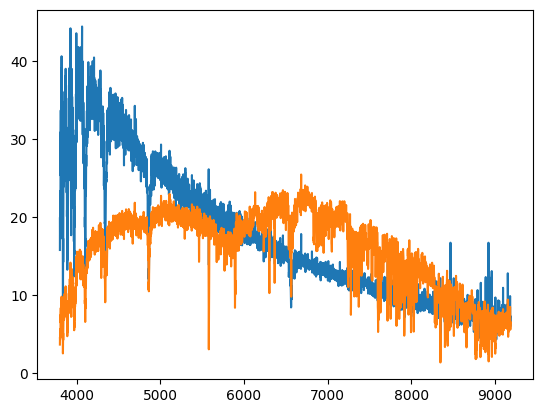

In [28]:
plt.plot(star_wave, star_flux)
plt.plot(star_wave, star_snr)
plt.show()

In [29]:
star_2_sdss = sdss_data["1000-323-52643"]
star_2_wave = star_2_sdss["wavelength_grid"][:]
star_2_flux = star_2_sdss["flux"][:]
star_2_snr = star_2_sdss["snr"][:]

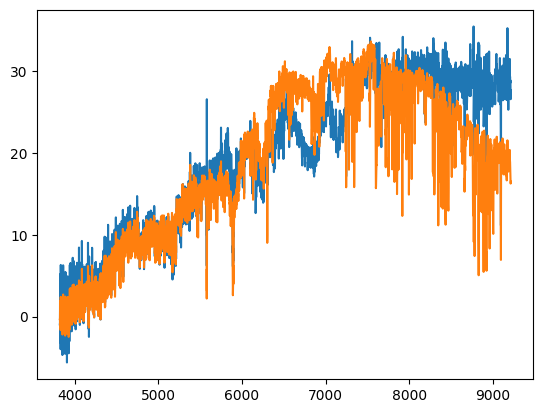

In [30]:
plt.plot(star_2_wave, star_2_flux)
plt.plot(star_2_wave, star_2_snr)
plt.show()

In [31]:
star_3_sdss = sdss_data["1000-405-52643"]
star_3_wave = star_3_sdss["wavelength_grid"][:]
star_3_flux = star_3_sdss["flux"][:]
star_3_snr = star_3_sdss["snr"][:]


[]

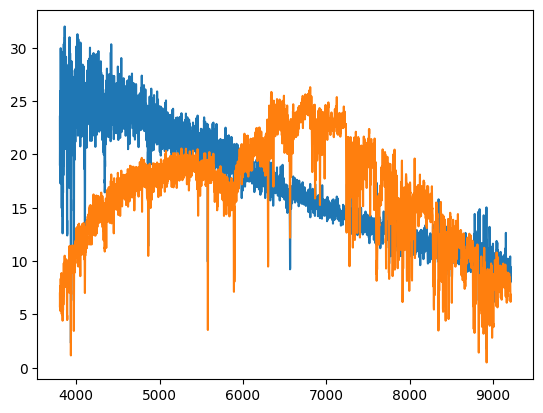

In [32]:
plt.plot(star_3_wave, star_3_flux)
plt.plot(star_3_wave, star_3_snr)
plt.plot()

signal-to-noise ratio drops in red and blue wavelength regions 

#### Masking and resampling the spectra

In [37]:
LAMBDA_START = 4000
LAMBDA_END = 8500
NUM_PIXELS = 3800

reference_grid = np.linspace(LAMBDA_START, LAMBDA_END, NUM_PIXELS)
len(reference_grid)

3800

In [34]:
mask  = (star_wave >= LAMBDA_START) & (star_wave <= LAMBDA_END)

In [39]:
star_wave_masked = star_wave[mask]
star_flux_masked = star_flux[mask]
star_snr_masked = star_snr[mask]

In [40]:
import spectres

In [47]:
flux_resampled = spectres.spectres(
    reference_grid,
    star_wave_masked,
    star_flux_masked,
    fill = 0.0,
    verbose = False
)

flux_resampled

array([ 0.        , 35.18436426, 37.13555307, ...,  8.81590652,
        7.30793419,  6.45433378], shape=(3800,))

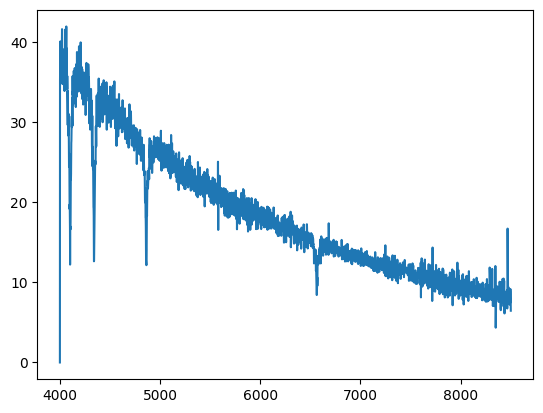

In [42]:
plt.plot(reference_grid, flux_resampled)
plt.show()

In [46]:
snr_resampled = np.interp(reference_grid, star_wave_masked, star_snr_masked)
snr_resampled

array([13.58278561, 13.21126607, 14.07018787, ...,  8.37313093,
        7.92129982,  7.59736586], shape=(3800,))

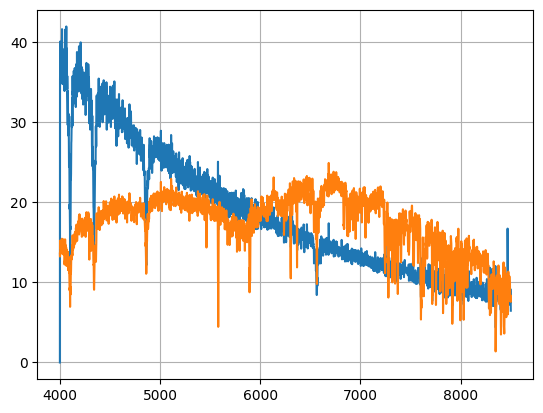

In [48]:
plt.plot(reference_grid, flux_resampled)
plt.plot(reference_grid, snr_resampled)
plt.grid()
plt.show()

In [62]:
from tqdm import tqdm

In [ ]:
def mask_resample(star_data):

    failed_ids = 0

    LAMBDA_START = 4000
    LAMBDA_END = 8500
    NUM_PIXELS = 3800

    reference_grid = np.linspace(LAMBDA_START, LAMBDA_END, NUM_PIXELS)

    results_dict = {}
    counter = 0
    for star in tqdm(star_data):
        
        if counter < 4:                        # For diagnosis
            star_wave = star_data[star]["wavelength_grid"][:]
            star_flux = star_data[star]["flux"][:]
            star_snr = star_data[star]["snr"][:]

            mask  = (star_wave >= LAMBDA_START) & (star_wave <= LAMBDA_END)

            star_wave_masked = star_wave[mask]
            star_flux_masked = star_flux[mask]
            star_snr_masked = star_snr[mask]

            if len(star_wave_masked) < 3000:
                failed_ids += 1
                continue

            try:
                flux_resampled = spectres.spectres(
                        reference_grid,
                        star_wave_masked,
                        star_flux_masked,
                        fill = 0.0,
                        verbose = False
                    )
                
                snr_resampled = np.interp(reference_grid, star_wave_masked, star_snr_masked)

                counter += 1

            except Exception as e:
                print(f"Failed star {star}")
                continue
        else:
            break

        results_dict[star] = {"wavelength_grid" : reference_grid,
                              "flux" : flux_resampled,
                              "snr" : snr_resampled}


    return results_dict

In [55]:
import gc

In [56]:
gc.collect()

2132

In [64]:
result_dict = mask_resample(sdss_data)

  0%|          | 4/21986 [00:00<15:43, 23.29it/s]


In [ ]:
result_dict

{'1000-198-52643': {'wavelength_grid': array([4000.        , 4001.18452224, 4002.36904449, ..., 8497.63095551,
         8498.81547776, 8500.        ], shape=(3800,)),
  'flux': array([ 0.        , 35.18436426, 37.13555307, ...,  8.81590652,
          7.30793419,  6.45433378], shape=(3800,)),
  'snr': array([13.58278561, 13.21126607, 14.07018787, ...,  8.37313093,
          7.92129982,  7.59736586], shape=(3800,))},
 '1000-323-52643': {'wavelength_grid': array([4000.        , 4001.18452224, 4002.36904449, ..., 8497.63095551,
         8498.81547776, 8500.        ], shape=(3800,)),
  'flux': array([ 0.        ,  2.54624175,  2.7374221 , ..., 28.72456169,
         26.04553467, 24.52904892], shape=(3800,)),
  'snr': array([-0.69540203,  1.71886924,  1.61519552, ..., 19.92346335,
         20.68648182, 21.25064278], shape=(3800,))},
 '1000-405-52643': {'wavelength_grid': array([4000.        , 4001.18452224, 4002.36904449, ..., 8497.63095551,
         8498.81547776, 8500.        ], shape=(3800

In [66]:
len(result_dict)

4

In [81]:
sdss_new_data = h5py.File("/home/arbiter/projects/Survey-invariant-generalization/data/sdss_resampled.h5")
len(sdss_new_data.keys())

OSError: Unable to synchronously open file (truncated file: eof = 1421344768, sblock->base_addr = 0, stored_eof = 2045860912)

In [75]:
sdss_new_data["1000-198-52643"].keys()

<KeysViewHDF5 ['flux', 'snr', 'wavelength_grid']>

In [76]:
len(sdss_new_data["1000-198-52643"]["flux"][:])

3800

In [77]:
len(sdss_new_data["1000-198-52643"]["wavelength_grid"][:])

3800

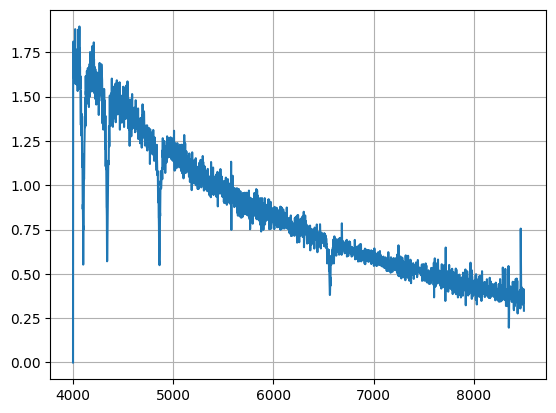

In [78]:
plt.plot(sdss_new_data["1000-198-52643"]["wavelength_grid"][:], sdss_new_data["1000-198-52643"]["flux"][:])
plt.grid()
plt.show()